# Homework 1 - Deep Learning Winter 2024

Student 1: Samih Warwar 324888155

Student 2: Merry Shalabi 324007202

# Qustion 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Printing about the data:

In [ ]:
import pandas as pd

# load
train_data = pd.read_csv('/content/drive/MyDrive/Deep_learning/part1_train.csv')

# print few of the data
print(train_data.head())
print("Column names:", train_data.columns)

# cleaning
train_data.columns = train_data.columns.str.strip()  # remove any leading/trailing spaces

print("Unique income values:", train_data['<=50K'].unique())

income_distribution = train_data['<=50K'].value_counts()
print("Income distribution:\n", income_distribution)

total_individuals = len(train_data)
percent_more_than_50k = (income_distribution[' >50K'] / total_individuals) * 100
percent_less_than_50k = (income_distribution[' <=50K'] / total_individuals) * 100

print(f"Percentage earning more than $50k: {percent_more_than_50k:.2f}%")
print(f"Percentage earning less than or equal to $50k: {percent_less_than_50k:.2f}%")

   39          State-gov   77516   Bachelors   13        Never-married  \
0  50   Self-emp-not-inc   83311   Bachelors   13   Married-civ-spouse   
1  38            Private  215646     HS-grad    9             Divorced   
2  53            Private  234721        11th    7   Married-civ-spouse   
3  28            Private  338409   Bachelors   13   Married-civ-spouse   
4  37            Private  284582     Masters   14   Married-civ-spouse   

         Adm-clerical   Not-in-family   White     Male   2174   0   40  \
0     Exec-managerial         Husband   White     Male      0   0   13   
1   Handlers-cleaners   Not-in-family   White     Male      0   0   40   
2   Handlers-cleaners         Husband   Black     Male      0   0   40   
3      Prof-specialty            Wife   Black   Female      0   0   40   
4     Exec-managerial            Wife   White   Female      0   0   40   

    United-States   <=50K  
0   United-States   <=50K  
1   United-States   <=50K  
2   United-States   <=50K 

Preparing the Data for training:

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# load
train_data = pd.read_csv('/content/drive/MyDrive/Deep_learning/part1_train.csv', header=None)
test_data = pd.read_csv('/content/drive/MyDrive/Deep_learning/part1_test.csv', header=None)

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

train_data.columns = column_names
test_data.columns = column_names

# convert 'income' into numeric values (0 for <=50K, 1 for >50K)
train_data['income'] = train_data['income'].apply(lambda x: 0 if x == ' <=50K' else 1)
test_data['income'] = test_data['income'].apply(lambda x: 0 if x == ' <=50K.' else 1)

# init
label_encoders = {}

categorical_columns = ['workclass', 'education', 'marital-status', 'occupation',
                       'relationship', 'race', 'sex', 'native-country']

# label it
for col in categorical_columns:
    le = LabelEncoder()
    train_data[col] = le.fit_transform(train_data[col])
    test_data[col] = le.transform(test_data[col])  # apply same encoding to test data
    label_encoders[col] = le

# seperate
X = train_data.drop(columns=['income'])
y = train_data['income']
X_test = test_data.drop(columns=['income'])
y_test = test_data['income']

# split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train)
X_val_df = pd.DataFrame(X_val)
X_test_df = pd.DataFrame(X_test)

# here the data is ready for training
print("Data preprocessing complete.")
print("First 5 rows of the preprocessed training data:")
print(X_train_df.head())
print("First 5 rows of the preprocessed test data:")
print(X_test_df.head())
print(y_test.head())
print(y_train.head())

Data preprocessing complete.
First 5 rows of the preprocessed training data:
         0         1         2         3         4         5         6   \
0 -0.408756 -1.286589  0.080051 -0.332671  1.133702  0.923471  0.810488   
1 -0.188857  0.088475 -0.981653 -0.590985  0.357049 -0.407828 -0.608779   
2  1.423734  1.463540  0.126197 -1.107613 -1.972910  1.589120 -0.845324   
3 -1.288351  0.088475 -0.090935 -0.590985  0.357049 -0.407828 -0.372234   
4 -0.848554  0.088475  0.856334  1.217214 -0.031277 -1.739126  0.337399   

         7         8         9         10        11        12        13  
0 -0.275318  0.395813 -1.418827 -0.145715 -0.217998  0.779460  0.292818  
1 -0.898166  0.395813  0.704807 -0.145715  4.457168  0.779460  0.292818  
2 -0.275318  0.395813  0.704807 -0.145715 -0.217998 -0.031510  0.292818  
3 -0.898166  0.395813  0.704807 -0.145715 -0.217998  0.455072  0.292818  
4 -0.275318  0.395813  0.704807 -0.145715 -0.217998 -0.031510  0.292818  
First 5 rows of the preproce

Now for the training:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Convert the data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

class FeedForwardNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FeedForwardNN, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size)  # First hidden layer
        self.fc2 = torch.nn.Linear(hidden_size, output_size)  # Output layer

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Apply ReLU activation
        x = self.fc2(x)  # Output layer
        return x

# Hyperparameters
input_size = X_train.shape[1]  # Number of features
hidden_size = 250  # Number of neurons in the hidden layer
output_size = 1  # Binary classification, one output unit
learning_rate = 0.005
num_epochs = 100

model = FeedForwardNN(input_size, hidden_size, output_size)
criterion = nn.BCEWithLogitsLoss()  # Use BCEWithLogitsLoss for binary classification
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training loop
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Calculate training accuracy
    train_preds = torch.sigmoid(outputs) > 0.5  # Apply sigmoid and threshold at 0.5
    train_accuracy = (train_preds.squeeze() == y_train_tensor.squeeze()).float().mean().item()

    # Append training loss and accuracy
    train_losses.append(loss.item())
    train_accuracies.append(train_accuracy)

    # Validation loop
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_preds = torch.sigmoid(val_outputs) > 0.5
        val_accuracy = (val_preds.squeeze() == y_val_tensor.squeeze()).float().mean().item()

        val_losses.append(val_loss.item())
        val_accuracies.append(val_accuracy)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {loss.item():.4f}, '
              f'Val Loss: {val_loss.item():.4f}, '
              f'Train Acc: {train_accuracy:.4f}, '
              f'Val Acc: {val_accuracy:.4f}')

Epoch [10/100], Train Loss: 0.4292, Val Loss: 0.4146, Train Acc: 0.7968, Val Acc: 0.8099
Epoch [20/100], Train Loss: 0.3892, Val Loss: 0.3806, Train Acc: 0.8213, Val Acc: 0.8245
Epoch [30/100], Train Loss: 0.3682, Val Loss: 0.3601, Train Acc: 0.8299, Val Acc: 0.8362
Epoch [40/100], Train Loss: 0.3499, Val Loss: 0.3429, Train Acc: 0.8379, Val Acc: 0.8389
Epoch [50/100], Train Loss: 0.3372, Val Loss: 0.3312, Train Acc: 0.8419, Val Acc: 0.8468
Epoch [60/100], Train Loss: 0.3291, Val Loss: 0.3247, Train Acc: 0.8456, Val Acc: 0.8509
Epoch [70/100], Train Loss: 0.3254, Val Loss: 0.3219, Train Acc: 0.8480, Val Acc: 0.8520
Epoch [80/100], Train Loss: 0.3235, Val Loss: 0.3210, Train Acc: 0.8494, Val Acc: 0.8535
Epoch [90/100], Train Loss: 0.3221, Val Loss: 0.3202, Train Acc: 0.8493, Val Acc: 0.8537
Epoch [100/100], Train Loss: 0.3208, Val Loss: 0.3196, Train Acc: 0.8498, Val Acc: 0.8529


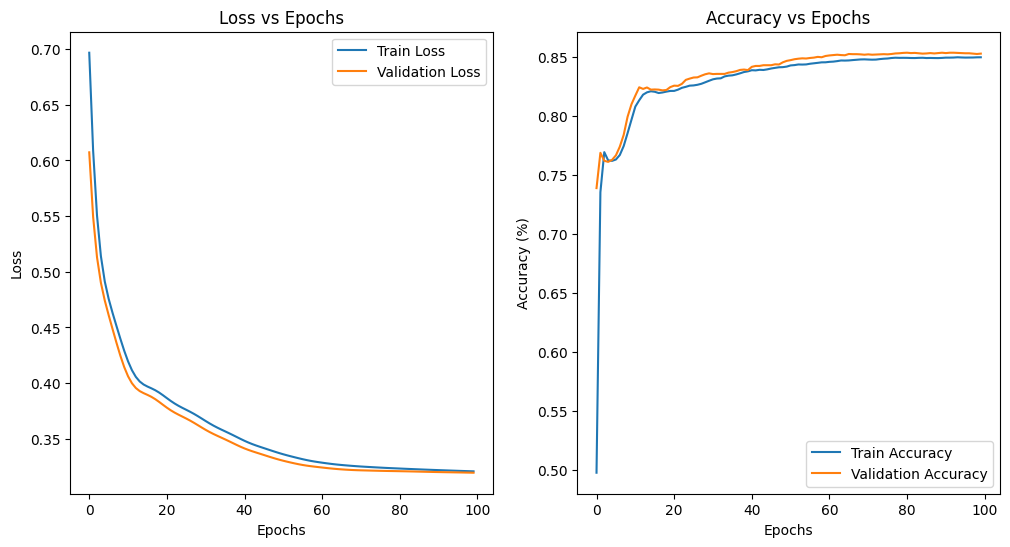

Model parameters: 4001
Layer details: [torch.Size([250, 14]), torch.Size([250]), torch.Size([1, 250]), torch.Size([1])]


In [ ]:
# Plot loss and accuracy
plt.figure(figsize=(12, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_losses, label='Train Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), train_accuracies, label='Train Accuracy')
plt.plot(range(num_epochs), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.show()

# Model summary
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Layer details: {[p.shape for p in model.parameters()]}")

In [ ]:
# Evaluate the model on the test dataset
model.eval()  # Set the model to evaluation mode

# No gradient calculation needed for inference
with torch.no_grad():
    # Get model outputs for the test data
    test_outputs = model(X_test_tensor)

    # Calculate test loss
    test_loss = criterion(test_outputs, y_test_tensor)

    # Calculate test accuracy
    test_preds = torch.sigmoid(test_outputs) > 0.5  # Apply sigmoid and threshold at 0.5
    test_accuracy = (test_preds.squeeze() == y_test_tensor.squeeze()).float().mean().item()

    print(f"Test Loss: {test_loss.item():.4f}")
    print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Test Loss: 0.3245
Test Accuracy: 85.06%


We used these hyperparameters after trying a bunch we ended up with
```
input_size = X_train.shape[1]  # Number of features
hidden_size = 250  # Number of neurons in the hidden layer
output_size = 1  # Binary classification, one output unit
learning_rate = 0.005
num_epochs = 100
```
we found the compination of this learning rate num ephocs and the hidden size is good we couldve also used less epochs according to the plot but 100 worked just fine.
we used 250 as the size of the hidden layer because the data is not too simple and also not too much compilcated, and becasue as we saw in the plots when we tried we got that using learning rate 0.005 got us a smooth progress.


# Qustion 2

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:

# Load and preprocess the FashionMNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Download the dataset
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split train_dataset for validation (80-20 split)
train_indices, val_indices = train_test_split(range(len(train_dataset)), test_size=0.2, random_state=42)
train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

# Dataloaders
batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



# Separate first 4 categories for Network 1
class_indices = [0, 1, 2, 3]

# Filter indices for classes 0, 1, 2, 3 from the training dataset
train_indices_4 = [i for i in train_indices if train_dataset.targets[i].item() in class_indices]
val_indices_4 = [i for i in val_indices if train_dataset.targets[i].item() in class_indices]
test_indices_4 = [i for i in range(len(test_dataset)) if test_dataset.targets[i].item() in class_indices]
# Create the subsets for the first 4 classes
train_subset_4 = Subset(train_dataset, train_indices_4)
val_subset_4 = Subset(train_dataset, val_indices_4)  # Use the same train_dataset for validation
test_subset_4 = Subset(test_dataset, test_indices_4)

train_loader_4 = DataLoader(train_subset_4, batch_size=batch_size, shuffle=True)
val_loader_4 = DataLoader(val_subset_4, batch_size=batch_size, shuffle=False)
test_loader_4 = DataLoader(test_subset_4, batch_size=batch_size, shuffle=False)


100%|██████████| 26.4M/26.4M [00:03<00:00, 7.40MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 118kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:02<00:00, 2.19MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 17.5MB/s]


Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



In [ ]:
class Network1(nn.Module):
    def __init__(self,input_size,output_size): #IN 28*28 OUT 4
        super(Network1, self).__init__()
        self.fc1 = nn.Linear(input_size, output_size)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input
        x = self.fc1(x)
        return x

class Network2(nn.Module):
    def __init__(self,input_size,hidden_size1,hidden_size2,output_size): #IN 28*28 OUT 10
        super(Network2, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, output_size)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the input
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [ ]:
input_size = 28*28
output_size = 4
learning_rate = 0.001
num_epochs = 30

Epoch 10/30: Train Accuracy = 0.9406, Validation Accuracy = 0.9358
Epoch 20/30: Train Accuracy = 0.9452, Validation Accuracy = 0.9345
Epoch 30/30: Train Accuracy = 0.9482, Validation Accuracy = 0.9364


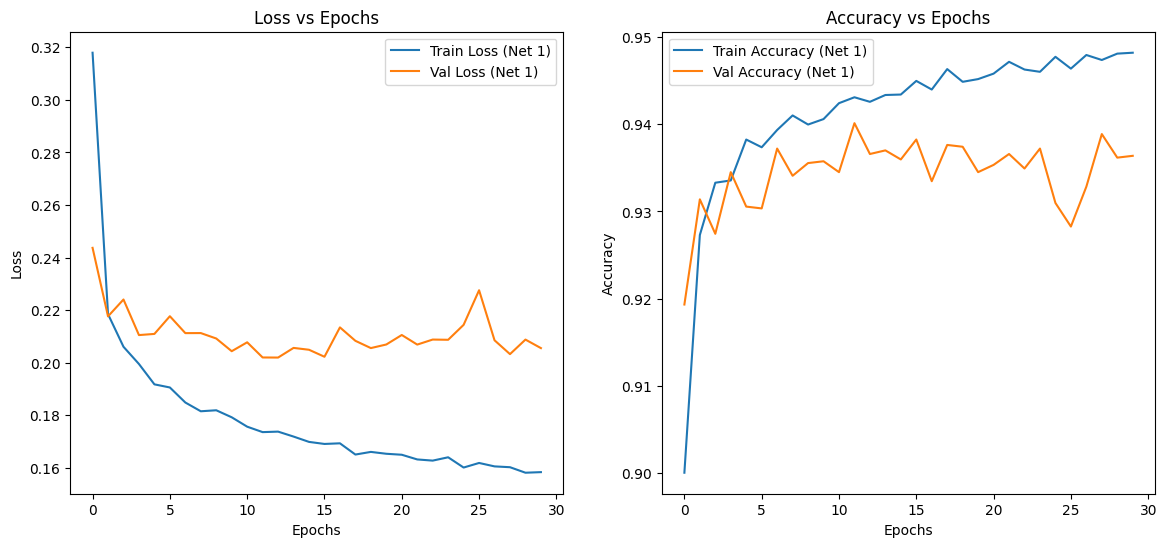

Total number of parameters in the model: 3140
Final Train Loss: 0.1583299433597989
Final Validation Loss: 0.20552610007740107
Final Train Accuracy: 0.9482021886399167
Final Validation Accuracy: 0.9363825363825364


In [ ]:
model = Network1(input_size, output_size).to(device)  # Move model to GPU
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training and validation
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader_4:
        inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_losses.append(running_loss / total)
    train_accuracies.append(correct / total)

    # Validation
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader_4:
            inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_losses.append(running_loss / total)
    val_accuracies.append(correct / total)

    # Print accuracy every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Accuracy = {train_accuracies[-1]:.4f}, "
              f"Validation Accuracy = {val_accuracies[-1]:.4f}")

# Plot loss and accuracy
plt.figure(figsize=(14, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss (Net 1)')
plt.plot(val_losses, label='Val Loss (Net 1)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy (Net 1)')
plt.plot(val_accuracies, label='Val Accuracy (Net 1)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.show()

print(f"Total number of parameters in the model: {sum(p.numel() for p in model.parameters())}")
print(f"Final Train Loss: {train_losses[-1]}")
print(f"Final Validation Loss: {val_losses[-1]}")
print(f"Final Train Accuracy: {train_accuracies[-1]}")
print(f"Final Validation Accuracy: {val_accuracies[-1]}")

In [ ]:
# Test the model
model.eval()
test_loss, correct, total = 0.0, 0, 0
with torch.no_grad():
    for inputs, labels in test_loader_4:
        inputs, labels = inputs.to(device), labels.to(device)  # Ensure labels are of type long
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss /= total
test_accuracy = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.2176
Test Accuracy: 0.9295


Here (the first part) we used
```
input_size = 28*28
output_size = 4
learning_rate = 0.001
num_epochs = 30
```
we found out that the data is not too complex so in just 30 epoch with 0.001 learning rate we could get good result.


In [ ]:
input_size = 28*28
hidden_size1 = 64
hidden_size2 = 32
output_size = 10
learning_rate = 0.0007
num_epochs = 30
min_delta=0.0005

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.stop_training = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop_training = True


Epoch 10/30: Train Accuracy = 0.8949, Validation Accuracy = 0.8769
Epoch 20/30: Train Accuracy = 0.9198, Validation Accuracy = 0.8868
Early stopping triggered at epoch 25


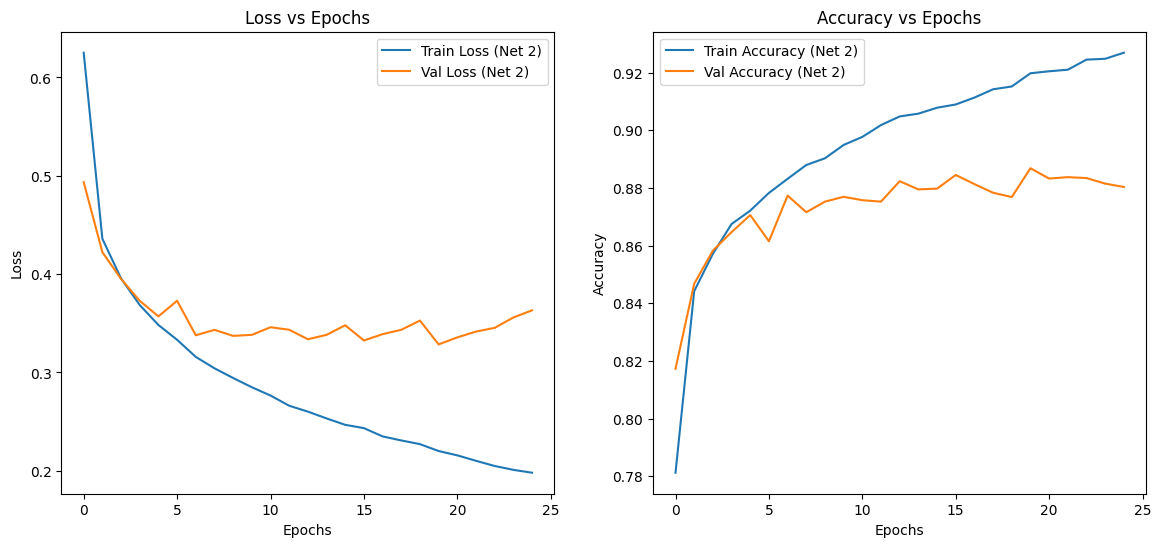

Total number of parameters in the model: 52650
Final Train Loss: 0.19808501156667868
Final Validation Loss: 0.3631865452925364
Final Train Accuracy: 0.9269166666666667
Final Validation Accuracy: 0.8803333333333333


In [ ]:
model2 = Network2(input_size, hidden_size1, hidden_size2,output_size).to(device)  # Move model to GPU
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=5, min_delta=min_delta)
# Training and validation
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # Training
    model2.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = model2(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_losses.append(running_loss / total)
    train_accuracies.append(correct / total)

    # Validation
    model2.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
            outputs = model2(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_losses.append(running_loss / total)
    val_accuracies.append(correct / total)

        # Check early stopping
    early_stopping(val_losses[-1])
    if early_stopping.stop_training:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

    # Print accuracy every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Accuracy = {train_accuracies[-1]:.4f}, "
              f"Validation Accuracy = {val_accuracies[-1]:.4f}")

# Plot loss and accuracy
plt.figure(figsize=(14, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss (Net 2)')
plt.plot(val_losses, label='Val Loss (Net 2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy (Net 2)')
plt.plot(val_accuracies, label='Val Accuracy (Net 2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.show()

print(f"Total number of parameters in the model: {sum(p.numel() for p in model2.parameters())}")
print(f"Final Train Loss: {train_losses[-1]}")
print(f"Final Validation Loss: {val_losses[-1]}")
print(f"Final Train Accuracy: {train_accuracies[-1]}")
print(f"Final Validation Accuracy: {val_accuracies[-1]}")

In [ ]:
# Test the model
model2.eval()
test_loss, correct, total = 0.0, 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Ensure labels are of type long
        outputs = model2(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss /= total
test_accuracy = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.3640
Test Accuracy: 0.8800


And finally here we used:
```
input_size = 28*28
hidden_size1 = 64
hidden_size2 = 32
output_size = 10
learning_rate = 0.0007
num_epochs = 30
min_delta=0.0005
```


We found that the data is not too complex, so we used input_size = 28*28, hidden_size1 = 64, hidden_size2 = 32, output_size = 10, learning_rate = 0.0007, and num_epochs = 30. These parameters helped the model perform well without overfitting. The learning rate was set low to ensure stable training, and the number of epochs was enough to achieve good results. The hidden layer sizes were chosen to be large enough to capture important patterns but small enough to keep the model efficient. Additionally, we used early stopping with min_delta = 0.0005 to prevent overfitting, stopping the training if the validation loss did not improve significantly.

For the comparison the first network we got better accuracy and its designed for a simpler task and has fewer parameters making it more efficient model but becasue the second network faces a more complex task requiring it to learn more complex patterns therfore the architechure will be more complex and has more hyperparameters